# Member 4 — DenseNet121 Transfer Learning

## Comparative Analysis of Deep Learning Architectures for Multi-Class Brain Tumour MRI Classification

**SE4050 – Deep Learning 2026**

This notebook implements a DenseNet121 transfer-learning model for classifying brain tumour MRI images into four classes: **glioma**, **meningioma**, **notumor**, and **pituitary**.

### Architectural Context & Scientific Comparison
DenseNet121 introduces **dense connectivity** across convolutional layers (Huang et al., 2017). While ResNet combines features through element-wise addition ($x + f(x)$), DenseNet concatenates all preceding feature maps ($[x_0, x_1, \dots, x_{l-1}]$). This architecture promotes maximum feature reuse, mitigates the vanishing-gradient problem, and substantially reduces parameter count relative to standard deep convolutional stacks (7.0M backbone parameters vs. 14.7M in VGG16 and 23.6M in ResNet50).

---

### Important Scientific Limitations
1. **Transfer Learning Limitation:** DenseNet121 starts from ImageNet pretrained weights, whereas Member 1's Custom CNN was trained from scratch. The comparison evaluates practical transfer-learning paradigms against custom from-scratch training, not an isolated architecture-only benchmark.
2. **Patient-Level Independence Limitation:** Patient-level independence could not be independently verified from the available dataset structure and identifiers. All analyses report image-level generalization.

---
## Phase 1 — Environment Verification and DenseNet121 Preprocessing Pipeline

**Goal:** Verify environment reproducibility, validate Member 1's frozen split manifests via SHA-256 checksums, and construct the DenseNet121-specific `tf.data` input pipeline.

### Phase 1 Tasks
1. Record complete runtime environment (Python, TensorFlow, Keras, NumPy, Pandas, scikit-learn, GPU, determinism).
2. Verify SHA-256 checksums for all three frozen split CSV files (`train.csv`, `val.csv`, `test.csv`).
3. Download exact Kaggle dataset version 1 (`masoudnickparvar/brain-tumor-mri-dataset/versions/1`).
4. Verify frozen sample counts: Train = 4,353, Validation = 1,089, Test = 1,311.
5. Verify frozen class mapping: `glioma: 0`, `meningioma: 1`, `notumor: 2`, `pituitary: 3`.
6. Verify that every referenced image file exists on disk.
7. Build DenseNet121-specific `tf.data` pipeline using `keras.applications.densenet.preprocess_input` (NO `Rescaling(1./255)`).
8. Apply common mild augmentation to training data only (rotation $\approx 0.03$, zoom $\approx \pm 0.08$, translation $\approx 0.05$).
9. Verify batch shapes, label integrity, and unshuffled validation stream.
10. Verify held-out test manifest without creating an evaluation dataset.
11. Save Phase 1 configuration and environment manifest.

### 1.1 — Install Dependencies and Imports

In [1]:
# Install kagglehub if not already present in environment
!pip install -q kagglehub

import os
import sys
import json
import hashlib
import time
import random
import platform
import shutil
import subprocess
import gc

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import sklearn
import kagglehub
import matplotlib
import matplotlib.pyplot as plt

# Architecture-specific preprocessor for DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

print("All imports completed successfully.")

All imports completed successfully.


### 1.2 — Set Random Seeds and Determinism

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    determinism_status = "TensorFlow op determinism enabled"
except Exception as e:
    determinism_status = f"Could not enable op determinism: {e}"

print(f"Seed:        {SEED}")
print(f"Determinism: {determinism_status}")

Seed:        42
Determinism: TensorFlow op determinism enabled


### 1.3 — Record Full Environment Information

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        gpu_name = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            text=True,
        ).strip().splitlines()[0]
        nvidia_smi = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name,driver_version,memory.total', '--format=csv,noheader'],
            text=True,
        ).strip().splitlines()[0]
    except Exception:
        gpu_name = tf.config.experimental.get_device_details(gpus[0]).get('device_name', 'Unknown GPU')
        nvidia_smi = 'Unavailable'
else:
    gpu_name = 'No GPU detected'
    nvidia_smi = 'N/A'

environment_info = {
    'member': 4,
    'model': 'DenseNet121',
    'python_version': sys.version,
    'platform': platform.platform(),
    'tensorflow_version': tf.__version__,
    'keras_version': keras.__version__,
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
    'scikit_learn_version': sklearn.__version__,
    'kagglehub_version': getattr(kagglehub, '__version__', 'unknown'),
    'matplotlib_version': matplotlib.__version__,
    'gpu_name': gpu_name,
    'nvidia_smi': nvidia_smi,
    'seed': SEED,
    'determinism_status': determinism_status,
}

print('Environment Recorded:')
for k, v in environment_info.items():
    print(f'  {k:<22}: {v}')

Environment Recorded:
  member                : 4
  model                 : DenseNet121
  python_version        : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
  platform              : Linux-6.6.122+-x86_64-with-glibc2.39
  tensorflow_version    : 2.20.0
  keras_version         : 3.13.2
  numpy_version         : 2.1.3
  pandas_version        : 2.2.3
  scikit_learn_version  : 1.6.1
  kagglehub_version     : 1.0.2
  matplotlib_version    : 3.10.0
  gpu_name              : No GPU detected
  nvidia_smi            : N/A
  seed                  : 42
  determinism_status    : TensorFlow op determinism enabled


### 1.4 — Download Pinned Kaggle Dataset (Version 1)

In [4]:
DATASET_HANDLE = "masoudnickparvar/brain-tumor-mri-dataset"
DATASET_VERSION = 1
PINNED_HANDLE = f"{DATASET_HANDLE}/versions/{DATASET_VERSION}"

dataset_path = kagglehub.dataset_download(PINNED_HANDLE)
print(f"Pinned Dataset Handle: {PINNED_HANDLE}")
print(f"Dataset downloaded to: {dataset_path}")
print(f"Dataset root contents: {os.listdir(dataset_path)}")

100%|██████████| 149M/149M [00:08<00:00, 17.4MB/s]

Extracting files...


Pinned Dataset Handle: masoudnickparvar/brain-tumor-mri-dataset/versions/1
Dataset downloaded to: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1
Dataset root contents: ['Testing', 'Training']


### 1.5 — Define Project Paths

In [5]:
from pathlib import Path
import os
import shutil
import subprocess

# ============================================================
# FRESH-COLAB PROJECT BOOTSTRAP — DENSENET121
# ============================================================

REPO_URL = (
    "https://github.com/ramzyhafeel/"
    "brain_tumour_model_comparison.git"
)

PROJECT_ROOT = Path(
    "/content/brain_tumour_model_comparison"
)


def ensure_project_available():
    """
    Ensure the complete project repository exists
    in the current Colab runtime.
    """

    required_items = [
        PROJECT_ROOT / "splits" / "train.csv",
        PROJECT_ROOT / "splits" / "val.csv",
        PROJECT_ROOT / "splits" / "test.csv",
        PROJECT_ROOT / "config" / "class_to_index.json",
        PROJECT_ROOT / "notebooks",
    ]

    if (
        PROJECT_ROOT.exists()
        and all(item.exists() for item in required_items)
    ):
        print("✓ Project repository already available.")
        return PROJECT_ROOT

    print("Project repository not found in this runtime.")
    print("Cloning GitHub repository...")

    # Remove incomplete project clone if present
    if PROJECT_ROOT.exists():
        shutil.rmtree(PROJECT_ROOT)

    subprocess.run(
        [
            "git",
            "clone",
            REPO_URL,
            str(PROJECT_ROOT),
        ],
        check=True,
    )

    missing = [
        str(item)
        for item in required_items
        if not item.exists()
    ]

    if missing:
        raise FileNotFoundError(
            "Repository cloned, but required files/folders "
            f"are missing:\n{missing}"
        )

    print("✓ Repository cloned successfully.")

    return PROJECT_ROOT


# ============================================================
# INITIALIZE PROJECT PATHS
# ============================================================

PROJECT_ROOT = ensure_project_available()

# Alias retained in case later cells use PROJECT_DIR
PROJECT_DIR = PROJECT_ROOT

SPLITS_DIR = PROJECT_ROOT / "splits"
CONFIG_DIR = PROJECT_ROOT / "config"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "densenet121"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "models"
    / "densenet121"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Split CSV variables used by later cells
TRAIN_CSV = SPLITS_DIR / "train.csv"
VAL_CSV = SPLITS_DIR / "val.csv"
TEST_CSV = SPLITS_DIR / "test.csv"

os.chdir(PROJECT_ROOT)


# ============================================================
# VERIFY PROJECT
# ============================================================

print("\n" + "=" * 70)
print("DENSENET121 PROJECT SETUP")
print("=" * 70)

print("Project root :", PROJECT_ROOT)
print("Splits       :", SPLITS_DIR)
print("Config       :", CONFIG_DIR)
print("Notebooks    :", NOTEBOOKS_DIR)
print("Results      :", RESULTS_DIR)
print("Models       :", MODELS_DIR)

print("\nSplit files:")
print("train.csv    :", TRAIN_CSV)
print("val.csv      :", VAL_CSV)
print("test.csv     :", TEST_CSV)

assert TRAIN_CSV.is_file(), (
    f"train.csv missing: {TRAIN_CSV}"
)

assert VAL_CSV.is_file(), (
    f"val.csv missing: {VAL_CSV}"
)

assert TEST_CSV.is_file(), (
    f"test.csv missing: {TEST_CSV}"
)

assert (
    CONFIG_DIR / "class_to_index.json"
).is_file(), (
    "class_to_index.json is missing."
)

print("\nWorking directory:", Path.cwd())

# dataset_path should already have been created by
# the earlier Kaggle dataset cell.
if "dataset_path" in globals():
    print("Dataset path :", dataset_path)
else:
    print(
        "Dataset path : not defined yet "
        "(it should be created by an earlier dataset cell)"
    )

print("\n✓ train.csv found")
print("✓ val.csv found")
print("✓ test.csv found")
print("✓ class_to_index.json found")
print("✓ DENSENET121 PROJECT READY")

Project repository not found in this runtime.
Cloning GitHub repository...
✓ Repository cloned successfully.

DENSENET121 PROJECT SETUP
Project root : /content/brain_tumour_model_comparison
Splits       : /content/brain_tumour_model_comparison/splits
Config       : /content/brain_tumour_model_comparison/config
Notebooks    : /content/brain_tumour_model_comparison/notebooks
Results      : /content/brain_tumour_model_comparison/results/densenet121
Models       : /content/brain_tumour_model_comparison/models/densenet121

Split files:
train.csv    : /content/brain_tumour_model_comparison/splits/train.csv
val.csv      : /content/brain_tumour_model_comparison/splits/val.csv
test.csv     : /content/brain_tumour_model_comparison/splits/test.csv

Working directory: /content/brain_tumour_model_comparison
Dataset path : /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1

✓ train.csv found
✓ val.csv found
✓ test.csv found
✓ class_to_index.json found
✓ DENSENET121 P

### 1.6 — Verify Frozen Split Checksums (SHA-256)

We verify the SHA-256 hashes of all three split CSV files against the frozen manifests created by Member 1.

In [6]:
EXPECTED_CHECKSUMS = {
    "train.csv": "7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb",
    "val.csv":   "37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f",
    "test.csv":  "9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39"
}

def compute_sha256(filepath):
    """Compute SHA-256 hash of a file."""
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

checksums_verified = True
computed_checksums = {}

for filename, expected_hash in EXPECTED_CHECKSUMS.items():
    filepath = os.path.join(SPLITS_DIR, filename)
    if not os.path.exists(filepath):
        print(f"ERROR: {filepath} missing!")
        checksums_verified = False
        continue

    actual_hash = compute_sha256(filepath)
    computed_checksums[filename] = actual_hash
    matches = (actual_hash == expected_hash)
    if not matches:
        checksums_verified = False

    status = "MATCH" if matches else "MISMATCH"
    print(f"{filename:<10}: {status}")
    print(f"  Expected: {expected_hash}")
    print(f"  Computed: {actual_hash}")

if not checksums_verified:
    raise RuntimeError("STOP: Split manifest checksum mismatch! Do not proceed.")
else:
    print("\nAll three split checksums verified successfully.")

train.csv : MATCH
  Expected: 7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
  Computed: 7273ef5fc2cb605c5b03b22a23cda0cb383ac0d9ce5949ac3c95649b5a4270cb
val.csv   : MATCH
  Expected: 37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
  Computed: 37b24456cfcd1b69df939e36603958eae6a9124b794c32c83a532b9018c6c88f
test.csv  : MATCH
  Expected: 9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39
  Computed: 9afc40a38949eb4f46f8c9591d3b1f51cdd11aa991bfe2cf1d15c386c5537d39

All three split checksums verified successfully.


### 1.7 — Load Split CSVs and Verify Sample Counts

In [7]:
train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(SPLITS_DIR, "val.csv"))
test_df  = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))

EXPECTED_TRAIN = 4353
EXPECTED_VAL   = 1089
EXPECTED_TEST  = 1311

print(f"Train samples: {len(train_df):<5} (expected {EXPECTED_TRAIN})")
print(f"Val samples:   {len(val_df):<5} (expected {EXPECTED_VAL})")
print(f"Test samples:  {len(test_df):<5} (expected {EXPECTED_TEST})")

assert len(train_df) == EXPECTED_TRAIN, f"Train count mismatch: {len(train_df)}"
assert len(val_df)   == EXPECTED_VAL,   f"Val count mismatch: {len(val_df)}"
assert len(test_df)  == EXPECTED_TEST,  f"Test count mismatch: {len(test_df)}"
print("\nAll sample counts match expected frozen split sizes.")

Train samples: 4353  (expected 4353)
Val samples:   1089  (expected 1089)
Test samples:  1311  (expected 1311)

All sample counts match expected frozen split sizes.


### 1.8 — Verify Class Names and Index Mapping

In [8]:
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

with open(os.path.join(CONFIG_DIR, "class_to_index.json"), "r") as f:
    frozen_class_mapping = json.load(f)

print("Class Mapping Verification:")
for name, idx in frozen_class_mapping.items():
    print(f"  {name:<12} -> {idx}")

assert CLASS_TO_INDEX == frozen_class_mapping, "Class mapping mismatch!"

# Verify class distributions in splits
for split_name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{split_name} Distribution:")
    dist = df["label"].value_counts().sort_index()
    for cls_name in CLASS_NAMES:
        print(f"  {cls_name:<12}: {dist.get(cls_name, 0)}")

Class Mapping Verification:
  glioma       -> 0
  meningioma   -> 1
  notumor      -> 2
  pituitary    -> 3

Train Distribution:
  glioma      : 1057
  meningioma  : 1064
  notumor     : 1080
  pituitary   : 1152

Validation Distribution:
  glioma      : 264
  meningioma  : 267
  notumor     : 270
  pituitary   : 288

Test Distribution:
  glioma      : 300
  meningioma  : 306
  notumor     : 405
  pituitary   : 300


### 1.9 — Verify That Every Referenced Image Exists on Disk

In [9]:
missing_images = []
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for _, row in df.iterrows():
        full_path = os.path.join(dataset_path, row["filepath"])
        if not os.path.isfile(full_path):
            missing_images.append((split_name, row["filepath"]))

if missing_images:
    print(f"ERROR: {len(missing_images)} images missing!")
    raise RuntimeError("Missing image files detected.")
else:
    total_images = len(train_df) + len(val_df) + len(test_df)
    print(f"All {total_images} referenced images verified on disk.")

All 6753 referenced images verified on disk.


---
## DenseNet121-Specific Preprocessing Pipeline

### Why `keras.applications.densenet.preprocess_input` instead of `Rescaling(1./255)`?

In Keras, `keras.applications.densenet.preprocess_input` standardizes image tensors according to PyTorch/TorchVision ImageNet conventions:
1. Scales pixel values from $[0, 255]$ to $[0, 1]$ via division by $255.0$.
2. Normalizes each color channel with ImageNet mean $[0.485, 0.456, 0.406]$ and standard deviation $[0.229, 0.224, 0.225]$.

**Critical Rule:** Applying `Rescaling(1./255)` before `densenet.preprocess_input` would cause **improper double division by 255**, shrinking pixels into $[0, 0.0039]$ before standardization, destroying image contrast and feature representation. The image decoder therefore outputs float32 values in $[0, 255]$, and `densenet.preprocess_input` handles the complete scaling and normalization.

### 1.10 — Define Pipeline Constants

In [10]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
CHANNELS     = 3
IMAGE_SIZE   = (IMAGE_HEIGHT, IMAGE_WIDTH)
INPUT_SHAPE  = (IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS)
BATCH_SIZE   = 16
NUM_CLASSES  = 4
MAX_EPOCHS   = 20

print(f"Image Shape:  {INPUT_SHAPE}")
print(f"Batch Size:   {BATCH_SIZE}")
print(f"Num Classes:  {NUM_CLASSES}")
print(f"Max Epochs:   {MAX_EPOCHS}")

Image Shape:  (224, 224, 3)
Batch Size:   16
Num Classes:  4
Max Epochs:   20


### 1.11 — Define Training-Only Augmentation Layer

Identical augmentation protocol across all models:
- Random Rotation: factor = 0.03 ($\approx \pm 10.8^\circ$)
- Random Zoom: $\pm 8\%$
- Random Translation: $5\%$
Applied **strictly to training data**.

In [11]:
def make_augmentation(seed=SEED):
    return tf.keras.Sequential([
        tf.keras.layers.RandomRotation(factor=0.03, seed=seed),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.08, 0.08),
            width_factor=(-0.08, 0.08),
            seed=seed,
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            seed=seed,
        ),
    ], name='augmentation')

# Preview/smoke instance. Each controlled experiment gets a fresh instance.
augmentation_layer = make_augmentation(SEED)
print('Training-only augmentation factory defined.')

Training-only augmentation factory defined.


### 1.12 — Build `tf.data` Pipeline with DenseNet121 Preprocessing

In [12]:
def decode_and_resize(filepath, label):
    """Decode JPEG, resize to 224x224 and keep float32 values in [0,255]."""
    raw = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def build_dataset(df, is_training=False):
    """Build raw-image tf.data pipeline. Model owns augmentation + preprocessing."""
    filepaths = [os.path.join(str(dataset_path), fp) for fp in df['filepath'].values]
    labels = [CLASS_TO_INDEX[lbl] for lbl in df['label'].values]
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if is_training:
        ds = ds.shuffle(
            buffer_size=len(filepaths),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    ds = ds.map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

print('DenseNet121 dataset builder defined.')
print('tf.data keeps pixels in raw [0,255] range; augmentation and DenseNet121 preprocess_input run exactly once inside the model.')

DenseNet121 dataset builder defined.
tf.data keeps pixels in raw [0,255] range; augmentation and DenseNet121 preprocess_input run exactly once inside the model.


### 1.13 — Instantiate Training and Validation Datasets

In [13]:
train_ds = build_dataset(train_df, is_training=True)
val_ds   = build_dataset(val_df,   is_training=False)

train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches   = tf.data.experimental.cardinality(val_ds).numpy()

print(f"Training Batches:   {train_batches} ({len(train_df)} images)")
print(f"Validation Batches: {val_batches} ({len(val_df)} images)")

Training Batches:   273 (4353 images)
Validation Batches: 69 (1089 images)


### 1.14 — Verify Pipeline Output Properties

We verify that:
1. Output tensor shape is `(16, 224, 224, 3)`.
2. Mean and variance standardization produces values centered near 0 with negative and positive bounds (confirming `densenet.preprocess_input` executed properly).
3. Validation dataset is strictly unshuffled.

In [14]:
sample_images, sample_labels = next(iter(train_ds))
print('Batch Image Shape:', sample_images.shape)
print('Batch Label Shape:', sample_labels.shape)
print('Image Dtype:', sample_images.dtype)
print('Raw Pixel Min:', float(tf.reduce_min(sample_images)))
print('Raw Pixel Max:', float(tf.reduce_max(sample_images)))
print('Sample Labels:', sample_labels.numpy())

assert tuple(sample_images.shape[1:]) == (224, 224, 3)
assert float(tf.reduce_min(sample_images)) >= 0.0
assert float(tf.reduce_max(sample_images)) <= 255.0 + 1e-3

processed_probe = densenet_preprocess_input(sample_images)
print('Preprocessed probe min:', float(tf.reduce_min(processed_probe)))
print('Preprocessed probe max:', float(tf.reduce_max(processed_probe)))
assert not np.allclose(processed_probe.numpy(), sample_images.numpy())
print('✓ Raw tf.data pipeline verified.')
print('✓ DenseNet121 preprocess_input transforms raw images and will be applied inside the model exactly once.')

expected_first_val_labels = [CLASS_TO_INDEX[l] for l in val_df['label'].values[:BATCH_SIZE]]
_, val_labels_batch = next(iter(val_ds))
actual_first_val_labels = val_labels_batch.numpy().tolist()
assert expected_first_val_labels == actual_first_val_labels, 'Validation dataset is shuffled!'
print('✓ Validation stream verified: unshuffled.')

Batch Image Shape: (16, 224, 224, 3)
Batch Label Shape: (16,)
Image Dtype: <dtype: 'float32'>
Raw Pixel Min: 0.0
Raw Pixel Max: 255.0
Sample Labels: [0 3 2 3 1 1 2 1 0 1 1 0 1 2 0 1]
Preprocessed probe min: -2.1179039478302
Preprocessed probe max: 2.640000104904175
✓ Raw tf.data pipeline verified.
✓ DenseNet121 preprocess_input transforms raw images and will be applied inside the model exactly once.
✓ Validation stream verified: unshuffled.


### 1.15 — Verify Held-Out Test Manifest (No Evaluation Dataset Created)

In [15]:
print("Held-Out Test Manifest Verification:")
print(f"  Total Test Images: {len(test_df)}")
for cls_name in CLASS_NAMES:
    count = int(np.sum(test_df["label"] == cls_name))
    print(f"    {cls_name:<12}: {count}")

print("\nTest manifest verified. No test evaluation dataset created.")

Held-Out Test Manifest Verification:
  Total Test Images: 1311
    glioma      : 300
    meningioma  : 306
    notumor     : 405
    pituitary   : 300

Test manifest verified. No test evaluation dataset created.


### 1.16 — Pipeline Visual Demonstration

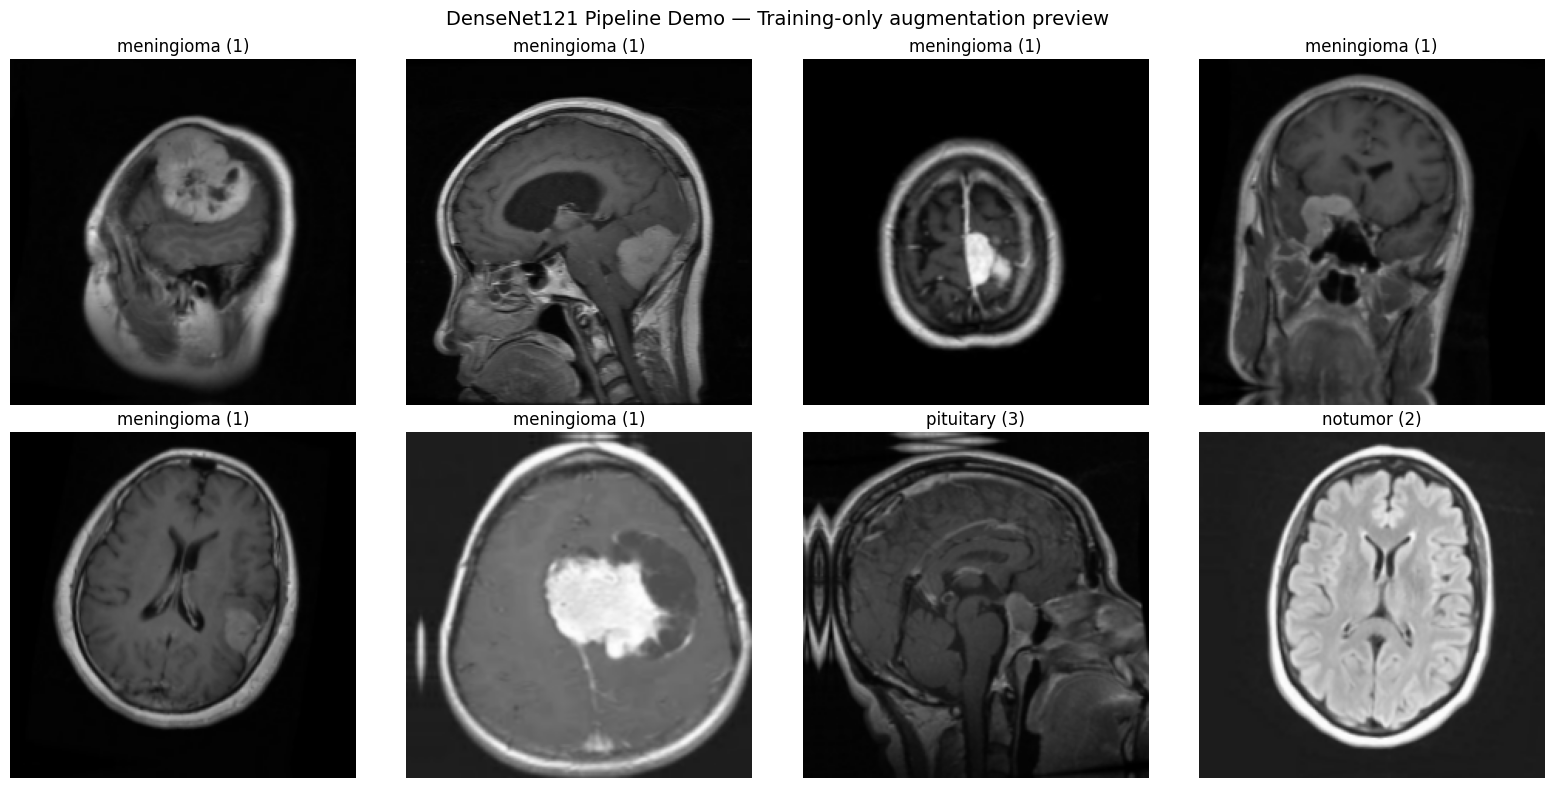

Pipeline demo saved to: /content/brain_tumour_model_comparison/results/densenet121/phase1_pipeline_demo.png
Processed probe range: -2.1179039478302 to 2.640000104904175


In [16]:
raw_images, demo_labels = next(iter(train_ds))
demo_aug = make_augmentation(SEED)
augmented_images = demo_aug(raw_images, training=True)
processed_images = densenet_preprocess_input(augmented_images)

# Display augmented raw RGB images (not the normalized tensor) for interpretability.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('DenseNet121 Pipeline Demo — Training-only augmentation preview', fontsize=14)
for i, ax in enumerate(axes.flat):
    if i >= raw_images.shape[0]:
        break
    vis = tf.clip_by_value(augmented_images[i], 0, 255).numpy().astype(np.uint8)
    ax.imshow(vis)
    ax.set_title(f'{CLASS_NAMES[int(demo_labels[i])]} ({int(demo_labels[i])})')
    ax.axis('off')
plt.tight_layout()
demo_plot_path = os.path.join(RESULTS_DIR, 'phase1_pipeline_demo.png')
plt.savefig(demo_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Pipeline demo saved to:', demo_plot_path)
print('Processed probe range:', float(tf.reduce_min(processed_images)), 'to', float(tf.reduce_max(processed_images)))

### 1.17 — Save Phase 1 Configuration and Environment Manifest

In [17]:
phase1_config = {
    "member": 4,
    "model": "DenseNet121",
    "phase": 1,
    "dataset_handle": DATASET_HANDLE,
    "dataset_version": DATASET_VERSION,
    "pinned_dataset_handle": PINNED_HANDLE,
    "dataset_path": dataset_path,
    "seed": SEED,
    "image_size": f"{IMAGE_HEIGHT}x{IMAGE_WIDTH}x{CHANNELS}",
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "max_epochs": MAX_EPOCHS,
    "class_names": CLASS_NAMES,
    "class_to_index": CLASS_TO_INDEX,
    "preprocessing": "keras.applications.densenet.preprocess_input (NO Rescaling 1/255)",
    "augmentation": {
        "rotation_factor": 0.03,
        "zoom_range": [-0.08, 0.08],
        "translation_factor": 0.05,
        "applied_to": "training_only"
    },
    "split_counts": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df)
    },
    "split_checksums": computed_checksums,
    "split_checksums_verified": True,
    "all_images_verified": True,
    "test_dataset_created_for_evaluation": False,
    "patient_level_split_verified": False,
    "transfer_learning_limitation": (
        "DenseNet121 uses ImageNet pretrained weights. The comparison with the Custom CNN "
        "(trained from scratch) is therefore a comparison of practical model/training "
        "approaches, not a perfectly isolated architecture-only comparison."
    ),
    "patient_level_limitation": (
        "Patient-level independence could not be independently verified from "
        "the available dataset structure and identifiers."
    )
}

config_path = os.path.join(RESULTS_DIR, "phase1_config.json")
with open(config_path, "w") as f:
    json.dump(phase1_config, f, indent=4)
print(f"Phase 1 config saved to: {config_path}")

env_path = os.path.join(RESULTS_DIR, "densenet121_environment.json")
with open(env_path, "w") as f:
    json.dump(environment_info, f, indent=4)
print(f"Environment manifest saved to: {env_path}")

Phase 1 config saved to: /content/brain_tumour_model_comparison/results/densenet121/phase1_config.json
Environment manifest saved to: /content/brain_tumour_model_comparison/results/densenet121/densenet121_environment.json


---
## Phase 1 — Complete

### Summary
1. **Environment Recorded:** Python, TensorFlow, Keras, NumPy, Pandas, scikit-learn, GPU, determinism.
2. **Split Checksums Verified:** Exact SHA-256 hashes matched for `train.csv`, `val.csv`, and `test.csv`.
3. **Dataset Version Pinned:** Downloaded exact Kaggle version 1.
4. **Split Counts Confirmed:** Train = 4,353, Validation = 1,089, Test = 1,311.
5. **DenseNet121 Preprocessing Established:** `densenet.preprocess_input` without double normalization.
6. **Augmentation:** Conservative training-only augmentation applied.
7. **Test Set Intact:** Test manifest verified; zero test evaluation performed.

**STOP — Do not proceed to Phase 2 until instructed.**

---
## Phase 2 — Frozen DenseNet121 Baseline and Smoke Test

**Goal:** Build a DenseNet121 transfer-learning model with a frozen ImageNet backbone and a modest classifier head, and execute a 1-epoch smoke test to verify end-to-end pipeline functionality.

### Architecture Design

```
Input (224x224x3)
  -> Augmentation (training only)
  -> densenet.preprocess_input
  -> DenseNet121 backbone (frozen, include_top=False, ImageNet weights)
  -> GlobalAveragePooling2D (1024 units)
  -> Dense(256, ReLU)
  -> Dropout(0.30)
  -> Dense(4, softmax)
```

### Theoretical Justifications

| Component | Design Choice | Technical Justification |
|---|---|---|
| **Backbone** | DenseNet121 (`imagenet`, frozen) | Dense convolutional network with 121 layers structured in 4 dense blocks with transition layers. Dense connectivity maximizes feature reuse and gradient flow while requiring only 7.04M parameters (compared to 14.7M in VGG16 and 23.6M in ResNet50). Backbone is frozen initially to preserve pretrained ImageNet filters. |
| **Pooling** | `GlobalAveragePooling2D` | Spatially collapses $(7 \times 7 \times 1024)$ feature maps into a 1,024-dimensional vector by averaging spatial dimensions. Avoids `Flatten` parameter explosion ($50,176$ units) and reinforces spatial invariance. |
| **Hidden Dense** | `Dense(256, activation='relu')` | Maps the 1,024 concatenated dense features to a 256-dimensional non-linear hidden representation. ReLU prevents gradient saturation. |
| **Regularization** | `Dropout(0.30)` | Regularization layer that randomly zeroes 30% of dense activations during training to reduce co-adaptation. |
| **Output Layer** | `Dense(4, activation='softmax')` | Produces normalized posterior class probabilities $(\sum p_i = 1.0)$ across the 4 tumour classes. |
| **Loss Function** | `SparseCategoricalCrossentropy` | Standard cross-entropy loss for multi-class classification with integer label encoding. |
| **Optimizer** | Adam ($\eta = 10^{-3}$) | Adaptive moment estimation optimizer for stable convergence when training the randomly initialized head. |

### 2.1 — Load Pretrained DenseNet121 Backbone

In [18]:
# Load DenseNet121 backbone with ImageNet weights, excluding the 1000-class classifier
base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers in the backbone
base_model.trainable = False

print(f"DenseNet121 backbone loaded with ImageNet weights.")
print(f"Backbone trainable:         {base_model.trainable}")
print(f"Total layers in backbone:   {len(base_model.layers)}")
print(f"Backbone output tensor:     {base_model.output_shape}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
DenseNet121 backbone loaded with ImageNet weights.
Backbone trainable:         False
Total layers in backbone:   427
Backbone output tensor:     (None, 7, 7, 1024)
